In [1]:
# import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm, colors
import matplotlib.patches as mpatches
import numpy as np
import awkward as ak
import h5py
from datetime import datetime, timezone
import os
import csv
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from lut import LUT
#from h5data import dereference
import cmcrameri.cm as cmc
import cmasher as cmr
from scipy.signal import savgol_filter, find_peaks
import numpy as np
from sklearn.cluster import DBSCAN
import plotly.graph_objects as go
import plotly.express as px
import pickle
from scipy.spatial import cKDTree
from scipy.optimize import minimize
import itertools
import time
import yaml
#f = '/global/cfs/cdirs/dune/users/yuxuan/NDLAr-full/samplePreparation/exampleSamples/MicroProdN4p1_NDComplex_FHC.flow.full.light.0002459.FLOW.hdf5'
f = '/pscratch/sd/d/dunepro/yuxuan/output/MiniProdN5/run-ndlar-flow/MiniProdN5p1_NDComplex_FHC.flow.full.lowintensity.sanddrift/FLOW/0000000/MiniProdN5p1_NDComplex_FHC.flow.full.lowintensity.sanddrift.0000001.FLOW.hdf5'
h5 = h5py.File(f,'r')
hits_dset = 'calib_prompt_hits'
hits_full = h5['charge/'+hits_dset+'/data']
hits_ref = h5['charge/events/ref/charge/'+hits_dset+'/ref']
ev_id = 0
TPCid = 4 #5 would have been a very good idea for demonstration purposed  #14 is pretty wierd
io1 = TPCid*2+1
io2 = TPCid*2+2
hits_event = hits_full[hits_ref[:, 0] == ev_id]
hits_tpc = hits_event[(hits_event['io_group'] == io1) | (hits_event['io_group'] == io2)]
xset = hits_tpc['x']
yset = hits_tpc['y']
zset = hits_tpc['z']
Eset = hits_tpc['E']
io_group = hits_tpc['io_group']
events = h5['charge/events/data']
with open("/global/cfs/cdirs/dune/users/yuxuan/NDLAr-full/samplePreparation/tpc_boundaries.yaml", "r") as f:
    chargeMap = yaml.safe_load(f)

sipm_rel_pos = LUT.from_array(h5["geometry_info/sipm_rel_pos"].attrs["meta"],h5["geometry_info/sipm_rel_pos/data"])
sipm_rel_pos_2 = LUT.to_array(sipm_rel_pos)# this one
hits_region = h5['charge/events/ref/charge/'+hits_dset+'/ref_region']
light_events = h5['light/events/data']
charge_light_ref = h5['charge/events/ref/light/events/ref']
charge_light_region = h5['charge/events/ref/light/events/ref_region']
light_wvfms = h5['light/wvfm/data']['samples']
light_event_wvfm_ref = h5['light/events/ref']['light/wvfm']['ref']
light_event_wvfm_region = h5['light/events/ref']['light/wvfm']['ref_region']
new_lookup_table = {}
NADC = 140  #You must update the NADC to 140 for the NDLAr Full
# Loop through all adc and channel values in the range
for adc in range(NADC):      # adc values from 0 to 4 or 0 to 140
    for channel in range(64):  # channel values from 0 to 63
        key = (adc, channel)
        # Retrieve [[TPC, side, y]] from the original lookup table
        try:
            tpc_side_y = sipm_rel_pos[(key)]
            TPC, side, y = tpc_side_y[0]
            # Assign (TPC, side, y) as the key and [adc, channel] as the value in the new lookup table
            new_lookup_table[(TPC, side, y)] = [adc, channel]
        except:
            print(str(adc) + ' and ' + str(channel) + ' excluded')

Total events: 67
Mean flashes per TPC per event (across present TPCs): 3.312
Median: 3.336


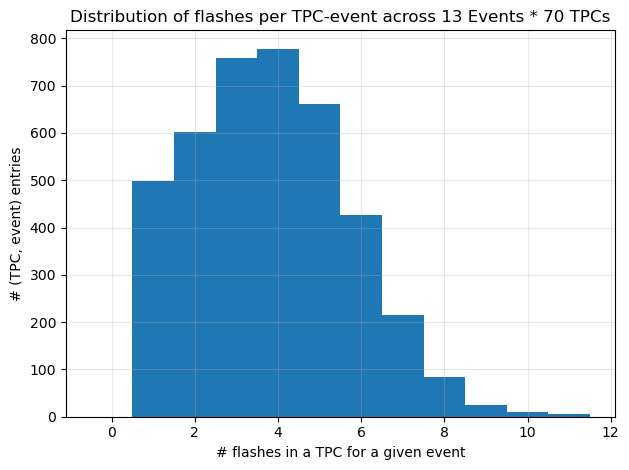

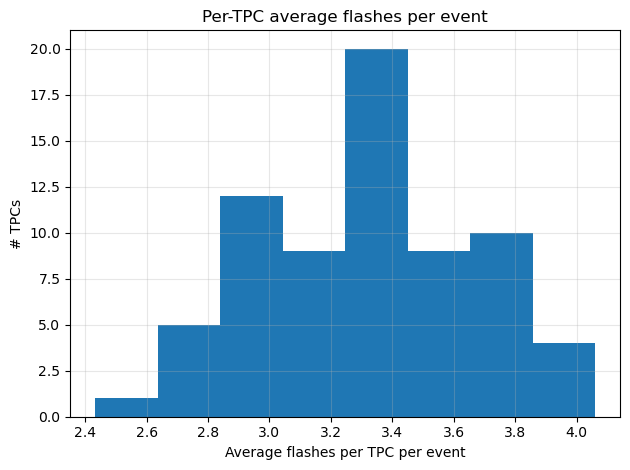

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Pull refs (event_id ↔ flash_id) and flash metadata
ref_ev_flash = h5['light/events/ref/light/flash/ref'][...]     # shape (Nref, 2) -> [event_id, flash_id]
flash_ids    = h5['light/flash/data']['id'][...]               # shape (Nflash,)
flash_tpcs   = h5['light/flash/data']['tpc'][...]              # shape (Nflash,)

# Map flash_id -> tpc
id_to_tpc = dict(zip(flash_ids.astype(int), flash_tpcs.astype(int)))

# Resolve each [event, flash] pair to [event, tpc]
ev = ref_ev_flash[:, 0].astype(np.int64)
fid = ref_ev_flash[:, 1].astype(int)
tpc = np.array([id_to_tpc.get(int(f), -1) for f in fid], dtype=np.int32)

# Drop any pairs that couldn't be mapped (should be none if ids align)
mask = tpc >= 0
ev = ev[mask]
tpc = tpc[mask]

# ----- (A) Flashes per TPC-event -----
# Count occurrences per (tpc, event)
pairs = np.stack([tpc, ev], axis=1)                                  # (Nref_valid, 2)
pairs_unique, counts_per_tpcev = np.unique(pairs, axis=0, return_counts=True)

# Histogram: integer counts per TPC-event
plt.figure()
bins = np.arange(0, counts_per_tpcev.max() + 2) - 0.5  # center on integers
plt.hist(counts_per_tpcev, bins=bins)
plt.xlabel("# flashes in a TPC for a given event")
plt.ylabel("# (TPC, event) entries")
plt.title("Distribution of flashes per TPC-event across 13 Events * 70 TPCs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('flash Distribution.png',dpi=500)


# ----- (B) Average flashes per TPC per event -----
# Sum flashes per TPC across events, then divide by #events
num_events_total = h5['light/events/data'].shape[0]  # total events seen by light/events

tpc_of_pair = pairs_unique[:, 0]  # TPC id for each (tpc, event) entry
# total flashes per TPC (sum the counts across events)
max_tpc_id = int(flash_tpcs.max()) if flash_tpcs.size else -1
totals_per_tpc = np.zeros(max_tpc_id + 1, dtype=np.int64)
np.add.at(totals_per_tpc, tpc_of_pair, counts_per_tpcev)

avg_per_tpc = totals_per_tpc / float(num_events_total)  # includes zeros for events without flashes

# Only plot TPCs that actually exist in the flash table (avoid empty tail if IDs are sparse)
present_tpcs = np.unique(flash_tpcs.astype(int))
avg_present  = avg_per_tpc[present_tpcs]

print(f"Total events: {num_events_total}")
print(f"Mean flashes per TPC per event (across present TPCs): {np.mean(avg_present):.3f}")
print(f"Median: {np.median(avg_present):.3f}")

plt.figure()
plt.hist(avg_present, bins='auto')
plt.xlabel("Average flashes per TPC per event")
plt.ylabel("# TPCs")
plt.title("Per-TPC average flashes per event")
plt.grid(True, alpha=0.3)
plt.tight_layout()


Total events: 67
Mean flashes per TPC per event (across all 70 TPCs): 3.312
Median: 3.336


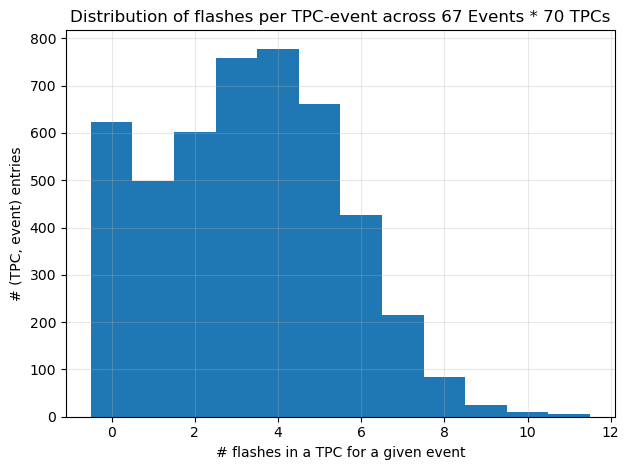

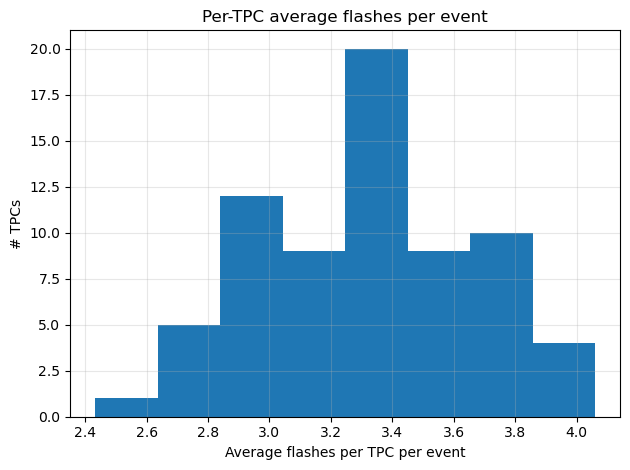

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Pull refs (event_id ↔ flash_id) and flash metadata
ref_ev_flash = h5['light/events/ref/light/flash/ref'][...]     # shape (Nref, 2) -> [event_id, flash_id]
flash_ids    = h5['light/flash/data']['id'][...]               # shape (Nflash,)
flash_tpcs   = h5['light/flash/data']['tpc'][...]              # shape (Nflash,)

# Map flash_id -> tpc
id_to_tpc = dict(zip(flash_ids.astype(int), flash_tpcs.astype(int)))

# Resolve each [event, flash] pair to [event, tpc]
ev = ref_ev_flash[:, 0].astype(np.int64)
fid = ref_ev_flash[:, 1].astype(int)
tpc = np.array([id_to_tpc.get(int(f), -1) for f in fid], dtype=np.int32)

# Drop any pairs that couldn't be mapped (should be none if ids align)
mask = tpc >= 0
ev = ev[mask]
tpc = tpc[mask]

# ----- (A) Flashes per TPC-event -----
# Count occurrences per (tpc, event)
pairs = np.stack([tpc, ev], axis=1)                                  # (Nref_valid, 2)
pairs_unique, counts_per_tpcev = np.unique(pairs, axis=0, return_counts=True)

# ====== FIX: INCLUDE THE 0-BIN ======
num_events_total = h5['light/events/data'].shape[0]  # total events seen by light/events
TOTAL_TPCS = 70 # As defined by the detector geometry

# Calculate how many (TPC, event) pairs have exactly 0 flashes
num_zero_pairs = (num_events_total * TOTAL_TPCS) - len(counts_per_tpcev)

# Append that many 0s to our counts array
counts_per_tpcev_full = np.concatenate([counts_per_tpcev, np.zeros(num_zero_pairs, dtype=int)])

# Histogram: integer counts per TPC-event
plt.figure()
bins = np.arange(0, counts_per_tpcev_full.max() + 2) - 0.5  # center on integers
plt.hist(counts_per_tpcev_full, bins=bins)
plt.xlabel("# flashes in a TPC for a given event")
plt.ylabel("# (TPC, event) entries")
plt.title(f"Distribution of flashes per TPC-event across {num_events_total} Events * {TOTAL_TPCS} TPCs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('flash_Distribution.png', dpi=500)


# ----- (B) Average flashes per TPC per event -----
# Sum flashes per TPC across events, then divide by #events
tpc_of_pair = pairs_unique[:, 0]  # TPC id for each (tpc, event) entry

# total flashes per TPC (sum the counts across events)
totals_per_tpc = np.zeros(TOTAL_TPCS, dtype=np.int64)
np.add.at(totals_per_tpc, tpc_of_pair, counts_per_tpcev)

avg_per_tpc = totals_per_tpc / float(num_events_total)  # includes zeros for events without flashes

print(f"Total events: {num_events_total}")
print(f"Mean flashes per TPC per event (across all {TOTAL_TPCS} TPCs): {np.mean(avg_per_tpc):.3f}")
print(f"Median: {np.median(avg_per_tpc):.3f}")

plt.figure()
plt.hist(avg_per_tpc, bins='auto')
plt.xlabel("Average flashes per TPC per event")
plt.ylabel("# TPCs")
plt.title("Per-TPC average flashes per event")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [4]:
import numpy as np

def get_single_flash_events(h5_file):
    """
    Identifies TPC-events that contain exactly one flash.
    
    Parameters:
    -----------
    h5_file : h5py.File
        The opened HDF5 file containing the light/flash and event data.
        
    Returns:
    --------
    single_flash_pairs : ndarray
        A 2D array of shape (N, 2) where each row is [event_id, tpc_id].
    """
    # Pull refs (event_id ↔ flash_id) and flash metadata
    ref_ev_flash = h5_file['light/events/ref/light/flash/ref'][...]
    flash_ids    = h5_file['light/flash/data']['id'][...]
    flash_tpcs   = h5_file['light/flash/data']['tpc'][...]
    
    # Map flash_id -> tpc
    id_to_tpc = dict(zip(flash_ids.astype(int), flash_tpcs.astype(int)))
    
    # Resolve each [event, flash] pair to [event, tpc]
    ev = ref_ev_flash[:, 0].astype(np.int64)
    fid = ref_ev_flash[:, 1].astype(int)
    tpc = np.array([id_to_tpc.get(int(f), -1) for f in fid], dtype=np.int32)
    
    # Drop any pairs that couldn't be mapped
    mask = tpc >= 0
    ev = ev[mask]
    tpc = tpc[mask]
    
    # Stack as [event_id, tpc_id] exactly as requested
    pairs = np.stack([ev, tpc], axis=1)
    
    # Count occurrences of each unique [event_id, tpc_id] pair
    pairs_unique, counts_per_tpcev = np.unique(pairs, axis=0, return_counts=True)
    
    # Filter for pairs that have exactly 1 flash
    single_flash_pairs = pairs_unique[counts_per_tpcev == 1]
    
    return single_flash_pairs
import numpy as np
from collections import defaultdict

import numpy as np
from collections import defaultdict

def get_single_flash_events_enhanced(h5_file):
    """
    Identifies TPC-events that contain:
      1) Exactly 1 flash, AND that flash has > 1 hits (filters out single-hit noise).
      - OR -
      2) Exactly 2 flashes, where one flash has exactly 1 hit and the other has >= 3 hits.
    
    Returns:
    --------
    valid_pairs : ndarray
        A 2D array of shape (N, 2) where each row is [event_id, tpc_id].
    """
    # Pull refs (event_id <-> flash_id) and flash metadata
    ref_ev_flash = h5_file['light/events/ref/light/flash/ref'][...]
    flash_ids    = h5_file['light/flash/data']['id'][...]
    flash_tpcs   = h5_file['light/flash/data']['tpc'][...]
    flash_hits   = h5_file['light/flash/data']['n_sum_hits'][...]
    
    # Map flash_id -> (tpc, n_sum_hits)
    id_to_tpc = dict(zip(flash_ids.astype(int), flash_tpcs.astype(int)))
    id_to_hits = dict(zip(flash_ids.astype(int), flash_hits.astype(int)))
    
    # Resolve each [event, flash] pair
    ev = ref_ev_flash[:, 0].astype(np.int64)
    fid = ref_ev_flash[:, 1].astype(int)
    
    tpc = np.array([id_to_tpc.get(int(f), -1) for f in fid], dtype=np.int32)
    hits = np.array([id_to_hits.get(int(f), 0) for f in fid], dtype=np.int32)
    
    # Drop any pairs that couldn't be mapped
    mask = tpc >= 0
    ev = ev[mask]
    tpc = tpc[mask]
    hits = hits[mask]
    
    # Group hits by (event, tpc) 
    groups = defaultdict(list)
    for e, t, h in zip(ev, tpc, hits):
        groups[(int(e), int(t))].append(h)
        
    valid_pairs = []
    
    for (e, t), hits_list in groups.items():
        n_flashes = len(hits_list)
        
        # Enhanced condition 1: Exactly 1 flash, but must have > 1 hits
        if n_flashes == 1:
            if hits_list[0] > 1:
                valid_pairs.append([e, t])
            
        # Enhanced condition 2: Exactly 2 flashes, one with 1 hit and the other with >= 3 hits
        elif n_flashes == 2:
            hits_list.sort()  # Sort ascending so hits_list[0] <= hits_list[1]
            if hits_list[0] == 1 and hits_list[1] >= 3:
                valid_pairs.append([e, t])
                
    if not valid_pairs:
        return np.empty((0, 2), dtype=np.int64)
        
    return np.array(valid_pairs, dtype=np.int64)


# --- Usage Example ---
single_flash_list = get_single_flash_events_enhanced(h5)
print(f"Found {len(single_flash_list)} single-flash TPC-events.")
print(single_flash_list[:5])  # Check the first 5 entries


Found 707 single-flash TPC-events.
[[ 0  9]
 [ 0 11]
 [ 0 21]
 [ 0 52]
 [ 1  6]]


In [5]:
# --- Usage Example ---
single_flash_list = get_single_flash_events(h5)
print(f"Found {len(single_flash_list)} single-flash TPC-events.")
print(single_flash_list[:5])  # Check the first 5 entries

Found 499 single-flash TPC-events.
[[ 0  9]
 [ 1  8]
 [ 1  9]
 [ 1 11]
 [ 1 13]]


In [6]:
def lightExtracter(fullLightWaveform, TPCid, new_lookup_table=new_lookup_table, baseline=-28000):
    """
    Extracts and optionally baseline-corrects light waveforms for a given TPC ID.

    Parameters
    ----------
    fullLightWaveform : ndarray
        Shape (140, 64, 1000) waveform for one event (e.g., light_wvfms[1])
    TPCid : int
        TPC ID (0 to 69) to extract waveforms for
    new_lookup_table : dict
        Maps (TPC, side, y) → [adc, channel]
    baseline : float or str
        - If baseline == 'auto': subtract mean of first 75 ticks per waveform
        - If baseline == any number: subtract that value from each waveform
        - If baseline == -28000 (default): add 28000 after converting to int32 to avoid overflow

    Returns
    -------
    output : ndarray
        Shape (N, 1000), baseline-corrected, ordered side 0 then side 1
    """
    side0 = []
    side1 = []

    for (tpc, side, y), (adc, ch) in new_lookup_table.items():
        if tpc == TPCid:
            waveform = fullLightWaveform[adc, ch, :]
            if side == 0:
                side0.append((y, waveform))
            elif side == 1:
                side1.append((y, waveform))

    # Sort by y-rel and stack
    side0_sorted = [wf for y, wf in sorted(side0, key=lambda tup: tup[0])]
    side1_sorted = [wf for y, wf in sorted(side1, key=lambda tup: tup[0])]
    stacked = np.vstack(side0_sorted + side1_sorted)
    stacked = stacked.astype(np.int32)
    # Apply baseline correction #when apply to data, enhance efficency by always doing this in auto mode 
    if baseline == 'auto':
        baseline_values = stacked[:, :75].mean(axis=1, keepdims=True)
        stacked = stacked - baseline_values
    elif baseline == -28000:
        stacked = stacked + 28000
    elif isinstance(baseline, (int, float)):
        stacked = stacked - baseline
    else:
        raise ValueError(f"Invalid baseline option: {baseline}")

    return stacked


def labeled_ultimate_drawer_ev(ev_id, hits_full, hits_ref, TPCid, actual, predicted=None, shift=0,
                                lookup_table=None, chargeMap=None, individualScaling=False):
    """
    Display charge hits in the center and light waveforms (actual vs. predicted) on the sides for a given TPC.

    Layout:
      - Left:  channels 0..59 bottom->top (labels L0..L59)
      - Right: channels 60..119 bottom->top (labels R0..R59)
      - Center: charge scatter (z vs y) with x as color
      - Far right: colorbar (spacer column inserted so it never crowds the right labels)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    import matplotlib.patches as mpatches
    import cmasher as cmr

    ROWS_PER_SIDE = 60  # 60 per side -> 120 channels total

    # --- colors/cmap ---
    cmap = cmr.get_sub_cmap('cmc.devon', 0.13, 0.95)

    # --- figure & outer layout ---
    # 5 columns: [left, center, right, spacer, colorbar]
    fig = plt.figure(figsize=(14.5, 21))
    outer_gs = gridspec.GridSpec(
        1, 5,
        width_ratios=[1.0, 1.6, 1.0, 0.25, 0.06],
        wspace=0.0
    )

    left_gs   = gridspec.GridSpecFromSubplotSpec(ROWS_PER_SIDE, 1, subplot_spec=outer_gs[0], hspace=0.0)
    center_ax = fig.add_subplot(outer_gs[1])
    right_gs  = gridspec.GridSpecFromSubplotSpec(ROWS_PER_SIDE, 1, subplot_spec=outer_gs[2], hspace=0.0)
    # spacer is outer_gs[3] (no axis created)
    cbar_ax   = fig.add_subplot(outer_gs[4])

    # --- hits selection for this event & TPC ---
    io_groups = [2 * TPCid + 1, 2 * TPCid + 2]

    # hits_ref assumed shape [..., 0]=event_id, [..., 1]=hit_id
    #hit_ids = hits_ref[hits_ref[:, 0] == ev_id, 1]
    hit_ids = np.where(hits_ref[:,0]==ev_id)[0]
    if hit_ids.size == 0:
        print(f"No hits found for event_id {ev_id}")
        return

    mask    = np.isin(hits_full['id'], hit_ids)
    hits_ev = hits_full[mask]
    hits_ev = hits_ev[np.isin(hits_ev['io_group'], io_groups)]
    ySet = hits_ev['y']
    zSet = hits_ev['z']
    xSet = hits_ev['x']
    E = np.sum(hits_ev['E'])
    print(f'Total energy of the event is {E}')
    # --- y-limits behavior for the light waveforms ---
    if individualScaling:
        global_ymin = np.nanmin(actual)
        global_ymax = np.nanmax(actual) + 10
        if predicted is not None and predicted.shape == actual.shape:
            global_ymin = min(global_ymin, float(np.nanmin(predicted))) - 3
            global_ymax = max(global_ymax, float(np.nanmax(predicted))) + 10

    # --- waveform panels (left/right), bottom-up placement ---
    NCH = int(actual.shape[0])
    for i in range(ROWS_PER_SIDE):
        # Data channel mapping: 0..59 -> left, 60..119 -> right
        ch_L = i
        ch_R = ROWS_PER_SIDE + i
        if max(ch_L, ch_R) >= NCH:
            break  # safety

        # Layout row index: bottom row is i=0 -> top row is ROWS_PER_SIDE-1
        row_idx = ROWS_PER_SIDE - 1 - i

        actual_L = actual[ch_L, :]
        actual_R = actual[ch_R, :]

        shifted_L = shifted_R = None
        if predicted is not None and predicted.shape == actual.shape:
            pred_L = predicted[ch_L, :]
            pred_R = predicted[ch_R, :]
            shifted_L = np.full_like(actual_L, np.nan, dtype=float)
            shifted_R = np.full_like(actual_R, np.nan, dtype=float)
            if shift > 0:
                shifted_L[shift:] = pred_L[:-shift]
                shifted_R[shift:] = pred_R[:-shift]
            elif shift < 0:
                shifted_L[:shift] = pred_L[-shift:]
                shifted_R[:shift] = pred_R[-shift:]
            else:
                shifted_L = pred_L.astype(float)
                shifted_R = pred_R.astype(float)

        if individualScaling:
            ymin, ymax = global_ymin, global_ymax
        else:
            vals = [actual_L, actual_R]
            if shifted_L is not None: vals += [shifted_L, shifted_R]
            ymin = min(float(np.nanmin(v)) for v in vals) - 3
            ymax = max(float(np.nanmax(v)) for v in vals) + 10

        # left stack row (bottom-up)
        ax_l = fig.add_subplot(left_gs[row_idx])
        ax_l.plot(actual_L, lw=0.8, color='#1f77b4')
        if shifted_L is not None:
            ax_l.plot(shifted_L, lw=0.8, color='#ff7f0e')
        ax_l.set_xlim(0, 1000)
        ax_l.set_ylim(ymin, ymax)
        ax_l.set_yticks([])
        ax_l.set_xticks([0, 250, 500, 750, 1000] if i == 0 else [])
        ax_l.set_ylabel(f'L{i}', rotation=0, labelpad=10, va='center')

        # right stack row (bottom-up)
        ax_r = fig.add_subplot(right_gs[row_idx])
        ax_r.plot(actual_R, lw=0.8, color='#1f77b4')
        if shifted_R is not None:
            ax_r.plot(shifted_R, lw=0.8, color='#ff7f0e')
        ax_r.set_xlim(0, 1000)
        ax_r.set_ylim(ymin, ymax)
        ax_r.set_yticks([])
        ax_r.set_xticks([0, 250, 500, 750, 1000] if i == 0 else [])
        ax_r.yaxis.set_label_position("right")
        ax_r.set_ylabel(f'R{i}', rotation=0, labelpad=10, va='center', ha='left')

    # ----- CHARGE PANEL -----
    y_fixed = (-215.5, 81.7)
    if TPCid not in chargeMap:
        raise KeyError(f"TPC {TPCid} missing from chargeMap")

    cm_t = chargeMap[TPCid]
    if 'z_min' in cm_t and 'z_max' in cm_t:
        zlim = (cm_t['z_min'], cm_t['z_max'])
    else:
        zlim = tuple(cm_t['z'])

    center_ax.set_xlim(zlim)
    center_ax.set_ylim(y_fixed)
    center_ax.set_aspect('auto')          # fill the center column
    center_ax.set_facecolor('black')

    border = mpatches.Rectangle((zlim[0], y_fixed[0]),
                                zlim[1] - zlim[0], y_fixed[1] - y_fixed[0],
                                linewidth=1, edgecolor='royalblue', facecolor='none', alpha=0.8)
    center_ax.add_patch(border)

    scatter = center_ax.scatter(zSet, ySet, c=xSet, cmap=cmap, s=2, marker='s')

    center_ax.set_yticks([])
    center_ax.set_xlabel("z")
    center_ax.set_title(f'Module {TPCid // 2}, TPC {TPCid}', fontsize=13)

    # colorbar (far right)
    cbar = plt.colorbar(scatter, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Charge x Position', rotation=90)

    # ----- Titles / legends (as requested) -----
    fig.suptitle('Single TPC Event Display', fontsize=16, y=0.93)
    fig.text(0.5, 0.91, 'Blue: Actual light waveforms from simulation', ha='center', color='#1f77b4', fontsize=12)
    if predicted is not None:
        fig.text(0.5, 0.89, 'Yellow: Predicted waveforms from charge readout', ha='center', color='#ff7f0e', fontsize=12)
    
    #plt.savefig('temp'+str(TPCid)+'.png',dpi = 500)
    plt.show()


The involved light TPC id is 3
Total energy of the event is 198.99801535728727


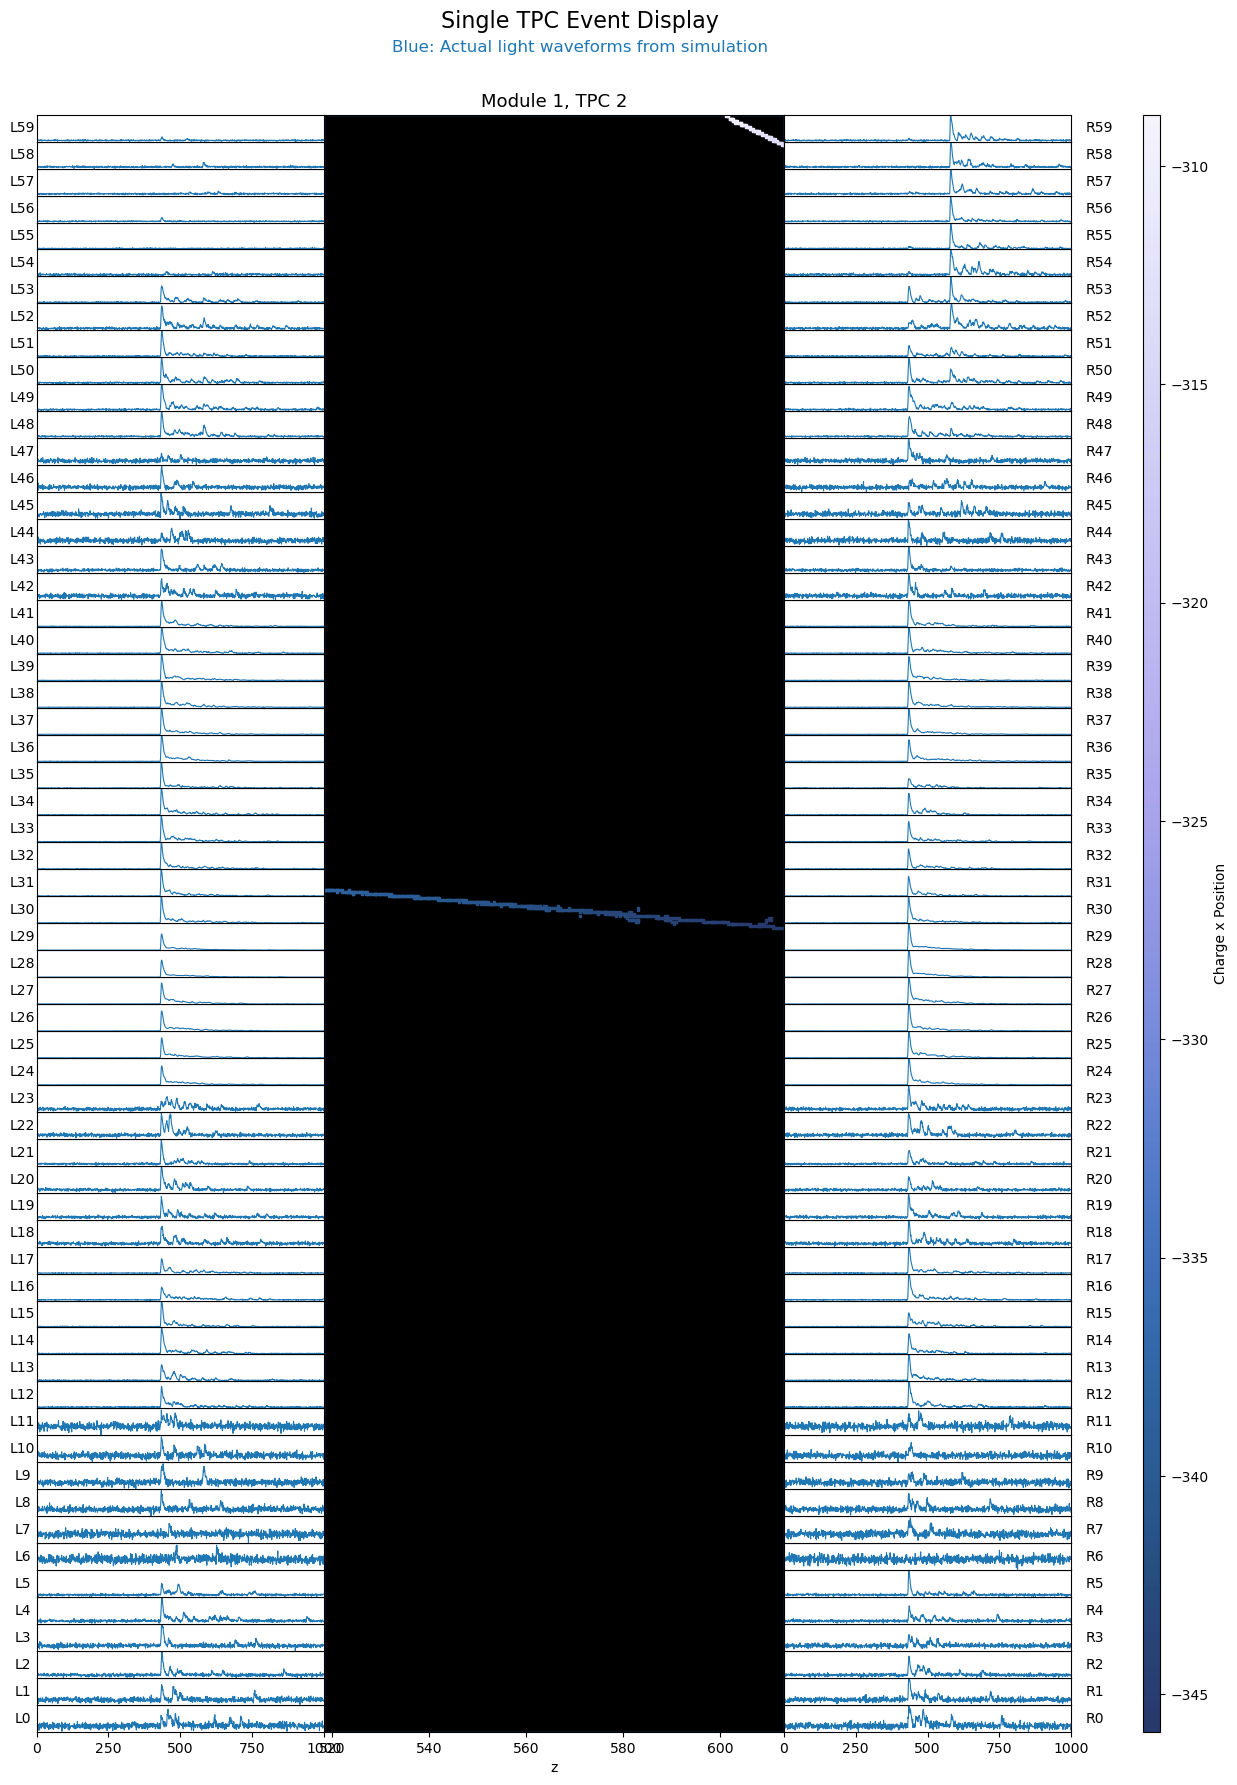

In [14]:
#4 5 8,9,10is reversed reversed 
event_id = 1
TPCid = 2
if len((np.where(charge_light_ref[:,0]==event_id)[0])) == 0:
    print('Light matching does not exist')
if len((np.where(hits_ref[:,0]==event_id)[0])) == 0:
    print('There is no charge hit in this TPC')
lightID = charge_light_ref[np.where(charge_light_ref[:,0]==event_id)[0][0]][1]
if TPCid %2 ==0:
    lightTPCid = TPCid+1
else:
    lightTPCid = TPCid - 1
print(f'The involved light TPC id is {lightTPCid}')
waveform = light_wvfms[lightID]
tpc12_waveform = lightExtracter(waveform, TPCid=lightTPCid)
labeled_ultimate_drawer_ev(
    ev_id=event_id,
    hits_full=hits_full,
    hits_ref=hits_ref,
    TPCid=TPCid,
    actual=tpc12_waveform,
    predicted=None,
    shift=0,
    lookup_table=new_lookup_table,
    chargeMap=chargeMap,
    individualScaling=False)


In [8]:
import numpy as np

def flashInfo(h5_file, eventid, tpcid):
    """
    Retrieves and prints information for all flashes in a specific event and TPC.
    
    Parameters:
    -----------
    h5_file : h5py.File
        The opened HDF5 file containing the light/flash and event data.
    eventid : int
        The event ID to query.
    tpcid : int
        The TPC ID to query.
        
    Returns:
    --------
    flash_list : list of dicts
        A list of dictionaries, where each dict contains the properties of a flash.
    """
    # 1. Find all flash IDs associated with the given eventid
    ref_ev_flash = h5_file['light/events/ref/light/flash/ref'][...]
    flash_refs_for_event = ref_ev_flash[ref_ev_flash[:, 0] == eventid]
    
    if len(flash_refs_for_event) == 0:
        print(f"No flashes found for event {eventid} overall.")
        return []
        
    event_flash_ids = flash_refs_for_event[:, 1]
    
    # 2. Get the flash data
    flash_data = h5_file['light/flash/data']
    
    # 3. Filter flashes that match BOTH the flash IDs from the event AND the requested tpcid
    flash_mask = np.isin(flash_data['id'], event_flash_ids) & (flash_data['tpc'] == tpcid)
    matched_flashes = flash_data[flash_mask]
    
    if len(matched_flashes) == 0:
        print(f"No flashes found for Event {eventid} in TPC {tpcid}.")
        return []
        
    print(f"Found {len(matched_flashes)} flash(es) for Event {eventid}, TPC {tpcid}:\n")
    
    flash_list = []
    
    # Check what fields are actually available in the flash data type
    available_fields = matched_flashes.dtype.names
    
    for i, flash in enumerate(matched_flashes):
        print(f"=== Flash {i+1} (ID: {flash['id']}) ===")
        flash_dict = {}
        for field in available_fields:
            val = flash[field]
            flash_dict[field] = val
            
            # If the field is a large array (like per-channel PEs/amplitudes), summarize it beautifully
            if isinstance(val, (np.ndarray, list)) and len(val) > 10:
                val_array = np.array(val)
                non_zero = np.sum(val_array > 0)
                if non_zero > 0:
                    max_val = np.max(val_array)
                    max_ch = np.argmax(val_array)
                    print(f"  {field:<15}: Array shape {val_array.shape} | Active channels: {non_zero} | Peak: {max_val:.2f} at index {max_ch}")
                else:
                    print(f"  {field:<15}: Array shape {val_array.shape} | All zeros")
            else:
                # Normal scalar values like time, tpc, etc.
                print(f"  {field:<15}: {val}")
                
        flash_list.append(flash_dict)
        print()
        
    return flash_list

# --- Usage Example ---
info = flashInfo(h5, eventid=0, tpcid=5)


Found 4 flash(es) for Event 0, TPC 5:

=== Flash 1 (ID: 18) ===
  id             : 18
  tpc            : 5
  n_sum_hits     : 24
  sample_range   : [396 398]
  hit_time_range : [4736. 4768.]
  rising_spline_range: [4736. 4768.]
  tot_sum        : 25528.125
  tot_max        : 3715.6298828125
  tot_sum_spline : 24008.6484375
  tot_max_spline : 3728.5830078125
  deconv_sum     : [[ 1.42851855e+03  1.44557532e+03  1.19691675e+03  1.22895679e+03
   4.65792725e+02  6.25052979e+02  3.52363472e+01  4.50996017e+01
   2.81927376e+01  3.98114052e+01  3.59677734e+01  2.11381531e+01
   1.36107040e+02  1.02845520e+02  9.92140045e+01  1.01953186e+02
   3.21131706e+01  5.93550568e+01  2.79769683e+00  3.45597839e+00
   2.57095528e+00  7.64338076e-01  1.78796577e+01 -2.74284005e-01
   2.39358482e+01  3.71124535e+01  1.25951214e+01  2.44917297e+01
   1.02070217e+01  1.12273579e+01 -5.11996746e-02 -3.25483680e-01
   2.70626903e-01 -5.30282378e-01 -9.87422347e-01  3.58763456e+00
   3.15609455e+00  9.208627

In [9]:
from cluster_fit import (
    fit_cluster_labels, fit_noise_list, dbscan_stats_string,
    plot_cluster_result, plot_phase3_candidate_hist
)
plot_cluster_result(xset,yset,zset)